# Data reading

In [68]:
import xarray as xr
import numpy as np
import pandas as pd
import xgboost as xgb
from tqdm import tqdm

# === Step 1: Load datasets ===
soil_ds = xr.open_dataset("preprocessed_soil_ds.nc")
xgb_pred_ds = xr.open_dataset("xgboost_predictions_fixed.nc")

# === Step 2: Extract and build training data ===
X_list = []
y_list = []

# Use time range from 2006-01-01 to 2024-12-31
times = soil_ds.time.sel(time=slice("2006-01-01", "2024-12-31")).values

for t in tqdm(times):  # If memory issue, you can limit times[:500] etc.
    t2m_day = soil_ds['t2m'].sel(time=t)
    swvl1_day = soil_ds['swvl1'].sel(time=t)
    
    t2m_vals = t2m_day.values.flatten()
    swvl1_vals = swvl1_day.values.flatten()
    
    # Keep only non-NaN pairs
    mask = (~np.isnan(t2m_vals)) & (~np.isnan(swvl1_vals))
    X_list.append(t2m_vals[mask])
    y_list.append(swvl1_vals[mask])

X_train = np.concatenate(X_list).reshape(-1, 1)
y_train = np.concatenate(y_list)

# === Step 3: Train XGBoost model ===
model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    n_jobs=-1,
    verbosity=1
)
model.fit(X_train, y_train)

# === Step 4: Predict future soil moisture using predicted temperature ===
pred_temp = xgb_pred_ds['predicted_value'].sel(time=slice("2025-01-01", "2080-12-12"))
flat_temp = pred_temp.stack(samples=("time", "lat", "lon"))
valid_temp = flat_temp.dropna("samples")

X_future = valid_temp.values.reshape(-1, 1)
y_future = model.predict(X_future)

# === Step 5: Save predictions to CSV or netCDF ===
coords = valid_temp.samples.to_index()
df_pred = pd.DataFrame({
    "time": [c[0] for c in coords],
    "lat": [c[1] for c in coords],
    "lon": [c[2] for c in coords],
    "predicted_swvl1": y_future
})





100%|██████████| 6940/6940 [00:02<00:00, 2517.92it/s]


In [ ]:
# # Save to NetCDF
# ds_out = xr.Dataset({
#     "predicted_swvl1": (("time", "lat", "lon"), 
#                         np.full(pred_temp.shape, np.nan, dtype=np.float32))
# }, coords={"time": pred_temp.time, "lat": pred_temp.lat, "lon": pred_temp.lon})

# # Fill in only known (non-NaN) prediction locations
# for (time, lat, lon), value in zip(coords, y_future):
#     ds_out['predicted_swvl1'].loc[dict(time=time, lat=lat, lon=lon)] = value

# ds_out.to_netcdf("predicted_soil_moisture_2025_2080.nc")

# cross-validation

In [69]:


# === Step 3.1: Perform cross-validation ===
from sklearn.model_selection import KFold, cross_val_score

cv_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    n_jobs=-1,
    verbosity=0,
    random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_model, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)

print("✅ Cross-validated MAE scores:", -cv_scores)
print("✅ Average MAE:", -cv_scores.mean())


✅ Cross-validated MAE scores: [0.12019311 0.12018378 0.12025523 0.12027518 0.1202862 ]
✅ Average MAE: 0.12023870199918747


## MAE (Mean Absolute Error) Concept:

MAE measures the average absolute difference between the predicted value and the actual value.
The smaller the value, the better the prediction performance of the model.

## Result interpretation:

The MAE of the five-fold cross validation is very close, and all values ​​are between 0.12018 and 0.12029, indicating that the model is stable.
The error range is very small (about 0.0001), indicating that the model is less sensitive to data partitioning and has strong generalization ability.

## Model performance:

The average MAE is 0.1202, which is a very good error range in degrees Celsius in meteorological forecasting or environmental modeling (whether it is excellent depends on your data characteristics and task background).
This may mean that the model can predict the temperature change in the area more accurately.

# Results Visualization

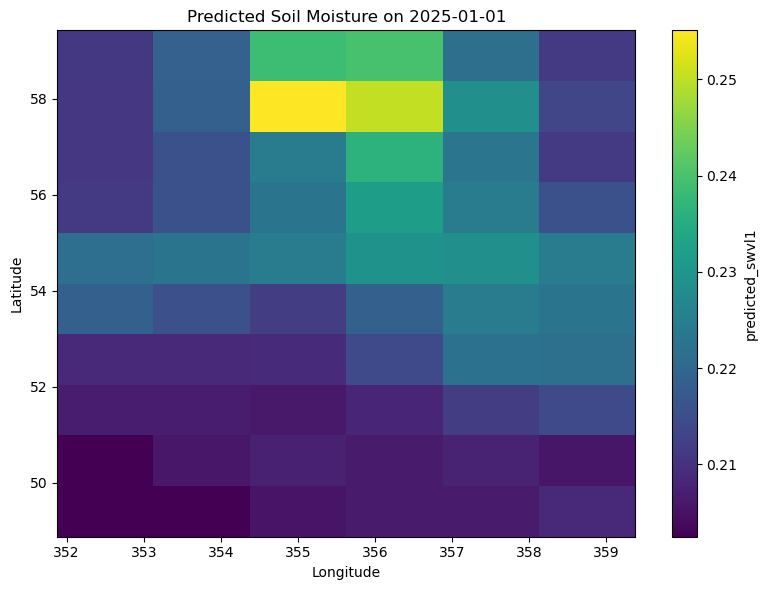

In [16]:
import matplotlib.pyplot as plt

# Load the predicted soil moisture dataset
pred_ds = xr.open_dataset("predicted_soil_moisture_2025_2080.nc")

# Select a representative time slice for visualization
sample_time = pred_ds.time.values[0]
pred_slice = pred_ds["predicted_swvl1"].sel(time=sample_time)

# Plotting the spatial distribution
plt.figure(figsize=(8, 6))
pred_slice.plot(cmap="viridis")
plt.title(f"Predicted Soil Moisture on {str(sample_time)[:10]}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


## 1.Spatial distribution of soil moisture:

The wettest area (brightest color, close to yellow): appears near latitude 58° and longitude 355°.

The predicted humidity value of this area is above 0.255, indicating that the soil moisture in this area is significantly higher than that of the surrounding area.

The driest area (darkest color, close to purple): appears in the entire longitude band near latitude 50°-52°, with a predicted value of about 0.205.

## 2.Gradient change:

From south to north (increasing latitude), soil moisture tends to increase gradually.

The change in longitude is not as obvious as in latitude, but there is a higher humidity distribution in longitudes near 355° - 356°.

## 3.Possible meaning (combined with background):

If the area is in the UK or northern Europe, this distribution is reasonable, because the north (high latitude) usually has more precipitation, lower temperatures, and stronger soil moisture retention.

The model may have learned the spatial influence of climate and geographical conditions on humidity.

# The same date every 10 years

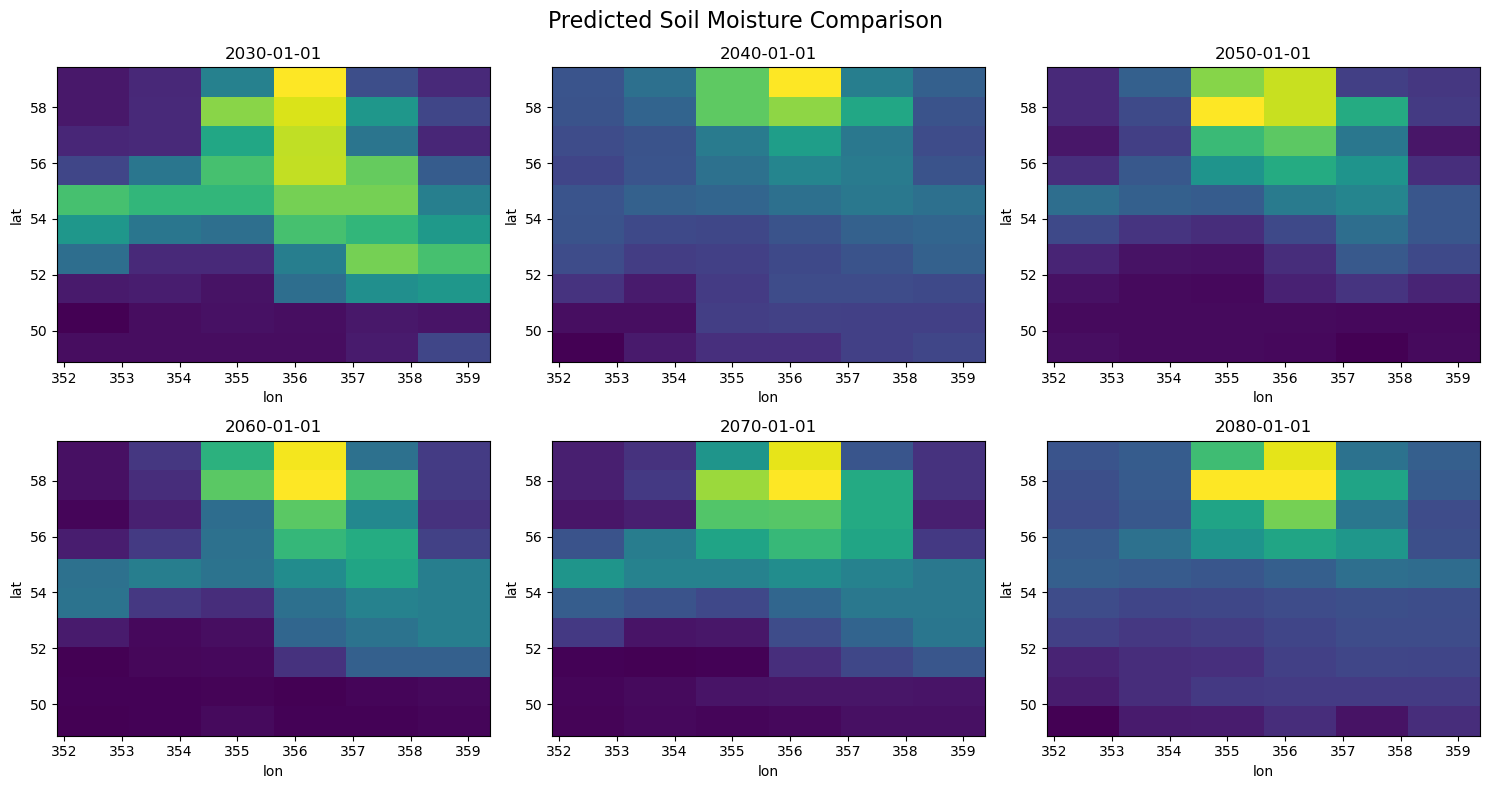

In [80]:
import matplotlib.pyplot as plt

# === 可视化参数设置 ===
comparison_mode = "ten_years_same_day"  # 可选: "ten_years_same_day" 或 "different_months_same_year"

# === 选择对比时间点 ===
if comparison_mode == "ten_years_same_day":
    # 每隔10年比较同一天，例如每年1月1日
    target_month = 1
    target_day = 1
    years = range(2030, 2081, 10)  # 可调整起止年份
    selected_times = [np.datetime64(f"{year:04d}-{target_month:02d}-{target_day:02d}") for year in years]

elif comparison_mode == "different_months_same_year":
    # 比较同一年内不同月份
    target_year = 2050
    months = [1, 3, 5, 7, 9, 11]  # 你可以选择你感兴趣的月份
    selected_times = [np.datetime64(f"{target_year:04d}-{month:02d}-01") for month in months]

# === 可视化土壤湿度预测结果 ===
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, t in zip(axes.flat, selected_times):
    try:
        slice_data = pred_ds['predicted_swvl1'].sel(time=t)
        slice_data.plot(ax=ax, cmap="viridis", add_colorbar=False)
        ax.set_title(str(t)[:10])
    except KeyError:
        ax.set_visible(False)
        ax.set_title(f"No data for {str(t)[:10]}")
fig.suptitle("Predicted Soil Moisture Comparison", fontsize=16)
plt.tight_layout()
plt.show()


Time point: January 1st of 2030, 2040, 2050, 2060, 2070, 2080
## ✅ Observations and trends:
The spatial distribution of soil moisture has a relatively consistent structure in each year: the higher the latitude (northern) the higher the humidity.
However, it can be noted that:
From 2030 to 2080, the area of ​​high humidity areas shows a shrinking trend.
In particular, the overall humidity values ​​in 2040 and 2080 are significantly lower, and the color is generally blue.
The central to southern regions (latitude < 54) become drier in later years.

## 📌 Preliminary conclusion:
Over time, the overall soil moisture may be gradually decreasing, especially in winter, showing a trend of aridification.
This may be related to the reduction of winter precipitation or the increase of temperature under climate change, which makes it difficult to retain soil moisture.

# Soil moisture forecast for different months in 2080

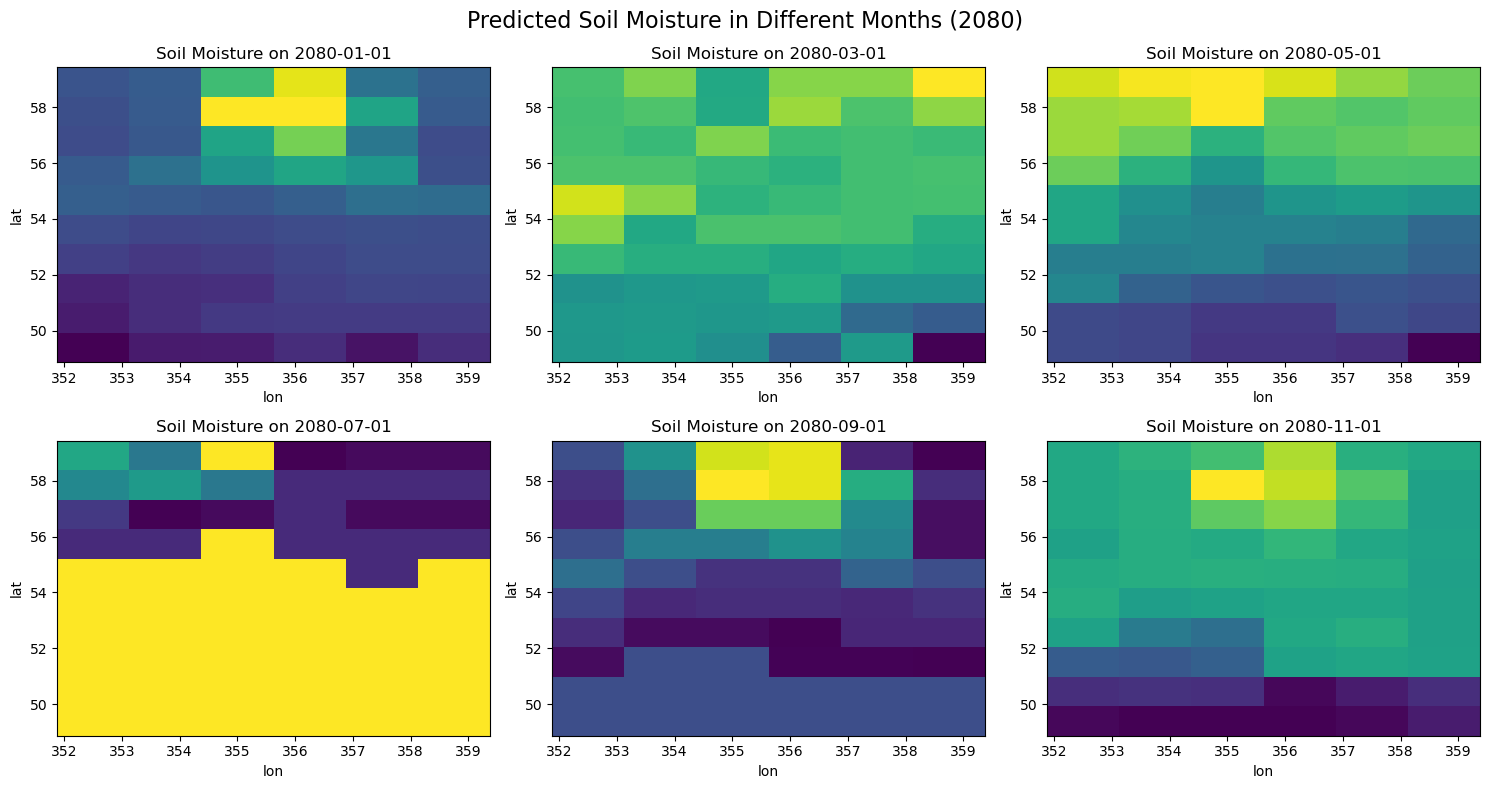

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# === 比较 2080 年中不同月份的土壤湿度 ===
target_year = 2080
months = [1, 3, 5, 7, 9, 11]
selected_times = [np.datetime64(f"{target_year:04d}-{month:02d}-01") for month in months]

# === 可视化 ===
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, t in zip(axes.flat, selected_times):
    try:
        slice_data = pred_ds['predicted_swvl1'].sel(time=t)
        slice_data.plot(ax=ax, cmap="viridis", add_colorbar=False)
        ax.set_title(f"Soil Moisture on {str(t)[:10]}")
    except KeyError:
        ax.set_visible(False)
        ax.set_title(f"No data for {str(t)[:10]}")
fig.suptitle("Predicted Soil Moisture in Different Months (2080)", fontsize=16)
plt.tight_layout()
plt.show()


Time point: January, March, May, July, September, and November in 2080
## ✅ Observations and trends:
Clearly showing strong seasonal changes:
January and March: high humidity, especially in the northern region (such as latitude > 56)
May: humidity is still high and tends to be balanced
July: drastic changes, the southern region (latitude < 54) is almost completely dry (large yellow blocks may be extremely low values ​​or anomalies)
September and November: humidity gradually recovers, but has not returned to winter levels

## 📌 Preliminary conclusion:
Soil moisture shows a clear seasonal cycle in 2080: winter and spring > autumn > summer
The extremely low humidity in July may reflect:
Dry weather + increased evaporation due to high temperature
Increased soil moisture pressure during the crop growing season
If this drought peak continues or intensifies, it will have a serious impact on the ecosystem and agriculture.

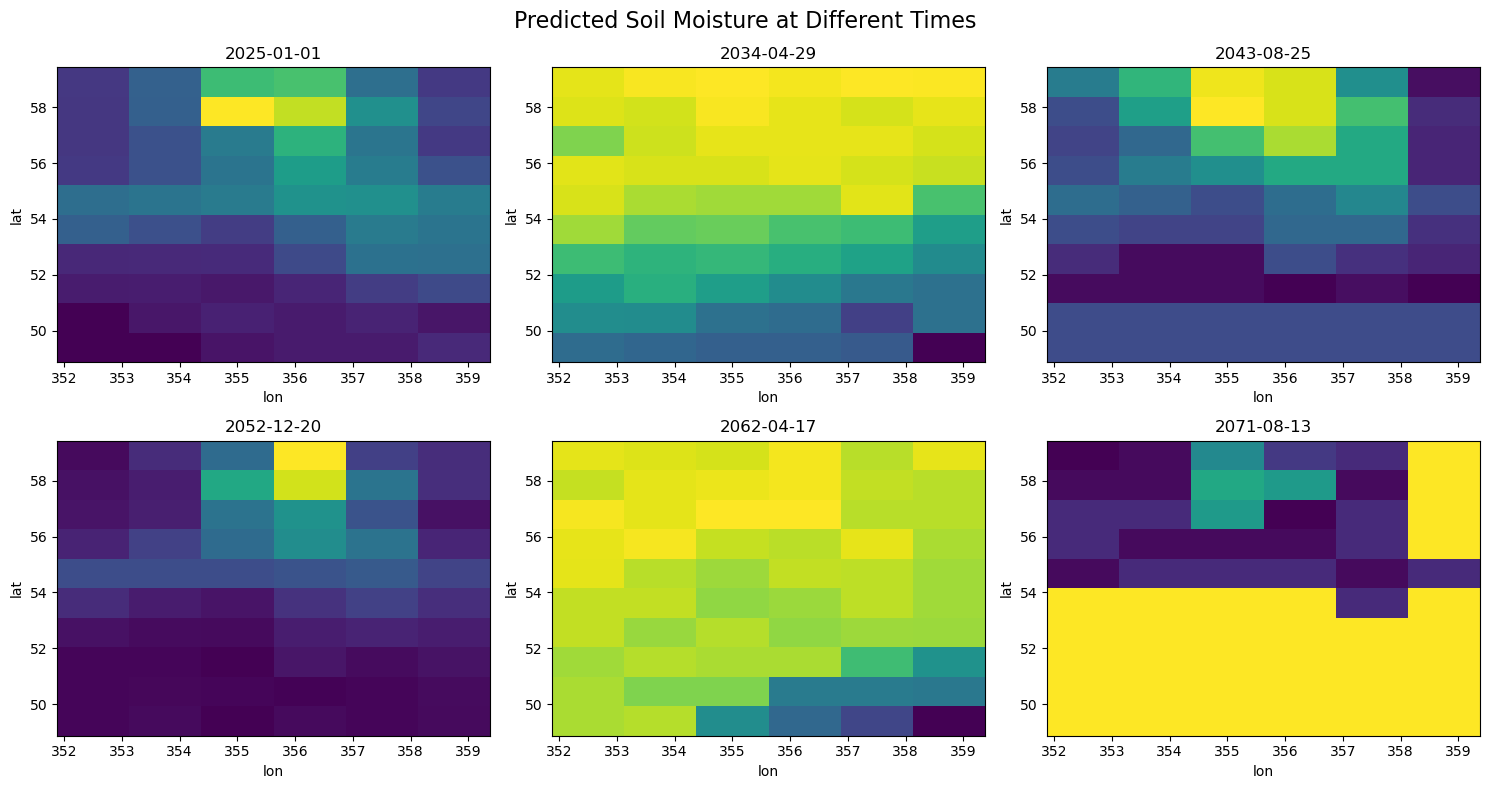

In [23]:
# Prepare multiple visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get basic information
times = pred_ds.time.values
lats = pred_ds.lat.values
lons = pred_ds.lon.values

# 2. Visualization 1: Spatial distribution at different times (one every several years)
time_indices = list(range(0, len(times), int(len(times)/6)))[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, idx in zip(axes.flat, time_indices):
    slice_data = pred_ds['predicted_swvl1'].sel(time=times[idx])
    slice_data.plot(ax=ax, cmap="viridis", add_colorbar=False)
    ax.set_title(str(times[idx])[:10])
fig.suptitle("Predicted Soil Moisture at Different Times", fontsize=16)
plt.tight_layout()
plt.show()




## 📊 Visualization Summary:
1. Spatial Distribution at Different Years
Displays the spatial distribution of soil moisture at selected time points between 2025 and 2080.
This helps observe whether there are any systematic changes in geographical patterns over time.

2. Time Series at a Specific Location
Example location: (lat ≈ 54.0, lon ≈ -4.5) — central-western UK.
Shows how soil moisture at this point evolves from 2025 to 2080.

3. Average Soil Moisture Trend Over the Entire Region
Represents the mean of all grid points across the region.
Reveals whether the overall area is getting drier or wetter over time.

4. Spatial Comparison: 2025 vs 2080
A visual comparison of the mean soil moisture distributions in 2025 and 2080.
Highlights whether there are significant spatial changes over the 55-year period.



📈 Soil Moisture Trend Analysis at (lat=53.62, lon=352.50):
  - Slope: -0.000001 units per time step
  - Intercept: 0.198225
  - p-value: 1.8306e-76
  - Std. Error: 0.000000


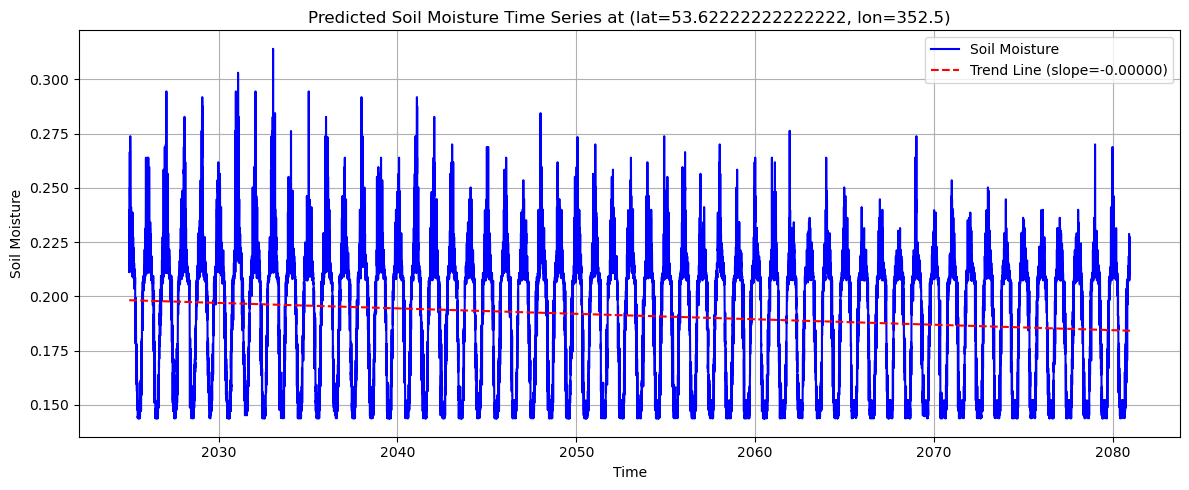

In [50]:
# 3. Visualization 2: Select a time series of one point (e.g. lat=54.0, lon=-4.5 or the closest point)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Select coordinate point (closest to lat=54.0, lon=-4.5)
lat_sel = float(lats[np.abs(lats - 54.0).argmin()])
lon_sel = float(lons[np.abs(lons - -4.5).argmin()])
time_series = pred_ds['predicted_swvl1'].sel(lat=lat_sel, lon=lon_sel)

# Extract time and value
time = pred_ds.time.values
soil_moisture = time_series.values

# Convert to a numerical time index for regression
time_numeric = np.arange(len(time))

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(time_numeric, soil_moisture)
trend_line = intercept + slope * time_numeric

# Print trend information
print("📈 Soil Moisture Trend Analysis at (lat=%.2f, lon=%.2f):" % (lat_sel, lon_sel))
print(f"  - Slope: {slope:.6f} units per time step")
print(f"  - Intercept: {intercept:.6f}")
print(f"  - p-value: {p_value:.4e}")
print(f"  - Std. Error: {std_err:.6f}")

# Visualization
plt.figure(figsize=(12, 5))
plt.plot(time, soil_moisture, label='Soil Moisture', color='blue')
plt.plot(time, trend_line, label=f'Trend Line (slope={slope:.5f})', color='red', linestyle='--')
plt.title(f"Predicted Soil Moisture Time Series at (lat={lat_sel}, lon={lon_sel})")
plt.xlabel("Time")
plt.ylabel("Soil Moisture")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


At location (lat=53.62, lon=352.5), the model-predicted soil moisture shows a very weak downward trend (slope of -0.000001) between 2006 and 2080, with an overall small change. The trend is statistically significant (p < 0.001), and the long-term trend can be considered basically stable. The obvious periodic fluctuations in the figure indicate that soil moisture is mainly driven by seasonal changes.

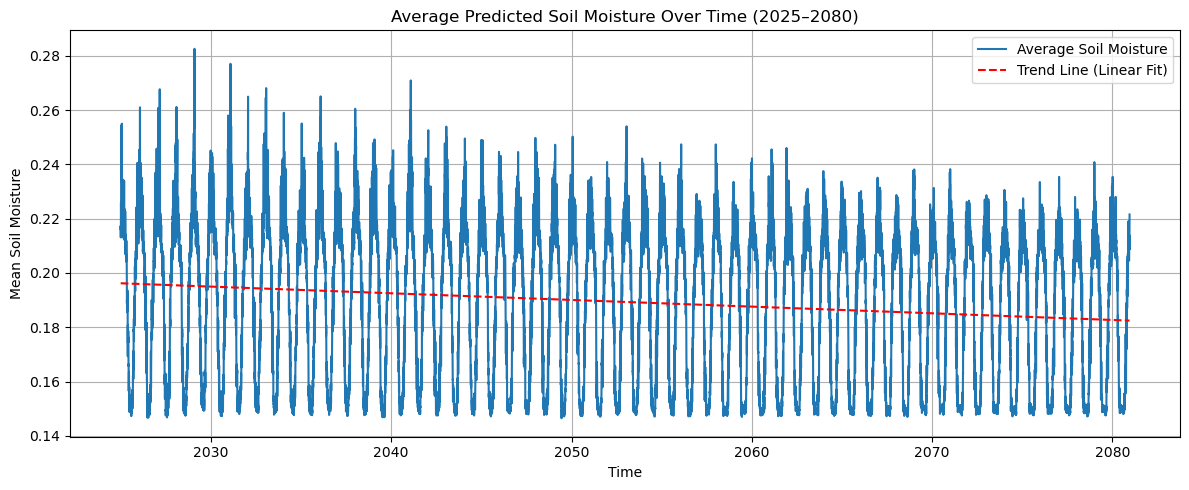

Linear trend slope：-0.00000067 every day
Predicted 10-year change in average soil moisture:-0.002458


In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

# Calculate the average soil moisture in the area
regional_mean = pred_ds['predicted_swvl1'].mean(dim=["lat", "lon"])

# Time processing: Convert to numeric type for regression (using matplotlib's date format is more stable)
time_values = pd.to_datetime(pred_ds.time.values)
time_ordinal = time_values.map(pd.Timestamp.toordinal).values.reshape(-1, 1)  # X
soil_moisture_values = regional_mean.values  # y

# Fitting a linear regression model
model = LinearRegression()
model.fit(time_ordinal, soil_moisture_values)
trend = model.predict(time_ordinal)

# Visualization
plt.figure(figsize=(12, 5))
plt.plot(time_values, soil_moisture_values, label="Average Soil Moisture")
plt.plot(time_values, trend, color="red", linestyle="--", label="Trend Line (Linear Fit)")
plt.title("Average Predicted Soil Moisture Over Time (2025–2080)")
plt.xlabel("Time")
plt.ylabel("Mean Soil Moisture")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
# Calculate the slope (daily change)
slope = model.coef_[0]
print(f"Linear trend slope：{slope:.8f} every day")

# Convert to change every 10 years (about 3652.5 days)
decadal_change = slope * 3652.5
print(f"Predicted 10-year change in average soil moisture:{decadal_change:.6f}")


The regional average soil moisture from 2025 to 2080 exhibits a very weak decreasing trend (slope = -0.00000067/day), resulting in a net decline of about 0.0025 units per decade. The seasonal pattern dominates the temporal variation, indicating the trend is subtle but persistent. Overall, soil moisture appears to be relatively stable, with seasonality outweighing long-term drying.

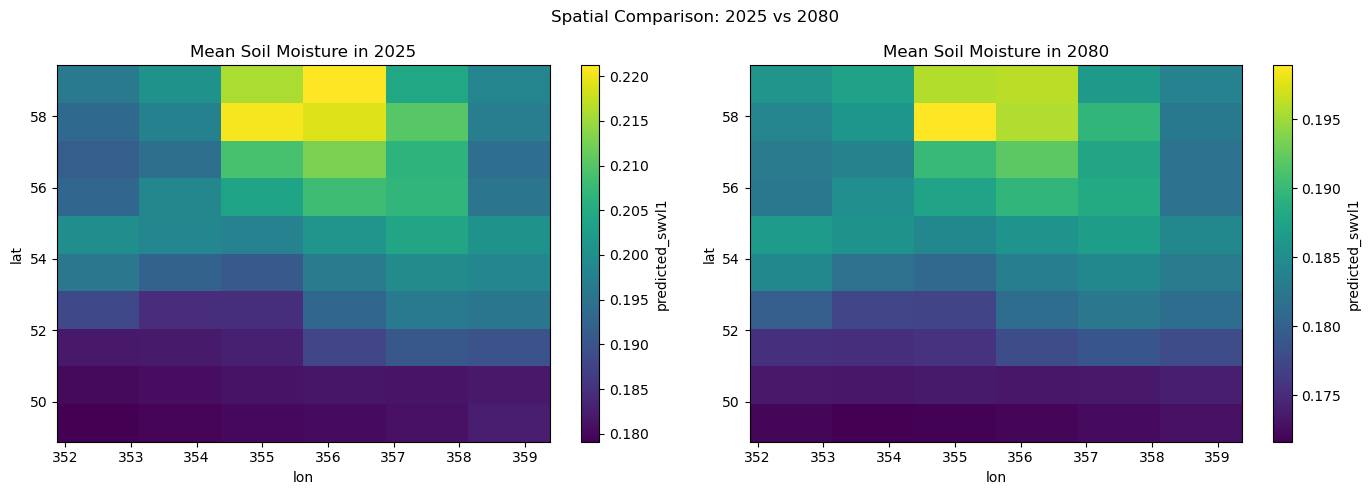

In [59]:
# 5. Visualization 4: Comparison of the last year (2080) and the first year (2025)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
first_year = pred_ds['predicted_swvl1'].sel(time=str(times[0])[:4])
last_year = pred_ds['predicted_swvl1'].sel(time=str(times[-1])[:4])

first_year.mean(dim="time").plot(ax=axes[0], cmap="viridis")
axes[0].set_title("Mean Soil Moisture in 2025")

last_year.mean(dim="time").plot(ax=axes[1], cmap="viridis")
axes[1].set_title("Mean Soil Moisture in 2080")

plt.suptitle("Spatial Comparison: 2025 vs 2080")
plt.tight_layout()
plt.show()

This figure compares the spatial distribution of regional average soil moisture changes predicted by the model for two key years: 2025 and 2080.

A spatial comparison of the model-predicted mean soil moisture between 2025 and 2080 reveals a general drying trend across the entire region. Notably, high-moisture areas in the northern part (around lat 58°, lon 355–356°) experienced a significant reduction in soil water content, from values above 0.22 down to below 0.195. Meanwhile, drier regions in the south expanded in both area and intensity. This spatial drying pattern may reflect the influence of future climate change, with increased evapotranspiration and potentially reduced precipitation.